In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s


In [2]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [1 ,2,0.1, 0.04]
b_coeffs = [1,2,0.041, 0.04]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
#expansion.plot_components()
# plt.xlabel('s')
# plt.xlim((0,1))

/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:96: UserWarning: The laplacian could not be evaluated
  warnings.warn("The laplacian could not be evaluated")


Scalar potential phi(x,y,s): 0.00166666666666667*x**4 + 0.0166666666666667*x**3 + x**2 + x + 0.00166666666666667*y**4 - y**3*(0.24*x + 0.246)/36 - y**2*(0.48*x**2 + 2.4*x + 48)/48 + y*(0.04*x**3 + 0.123*x**2 + 12*x + 6)/6
Scalar potential phi at (0.4,0.2,0.5): 0.8809133333333334


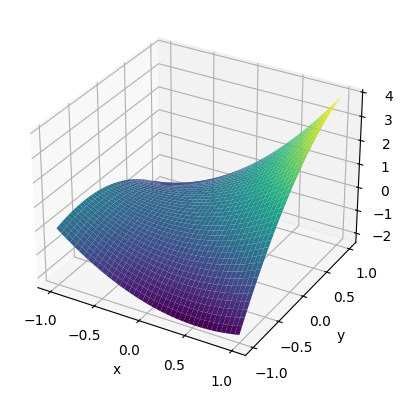

In [3]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
npoints=201
xa= np.linspace(-1,1,npoints) 
ya=np.linspace(-1,1,npoints)
sa=np.linspace(-1,1,npoints)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)

P = phi_func(X, Y, 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [4]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)#with lambdify=False
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)

In [5]:
print(X.shape)

(201, 201, 201)


Text(0.5, 0, 'x')

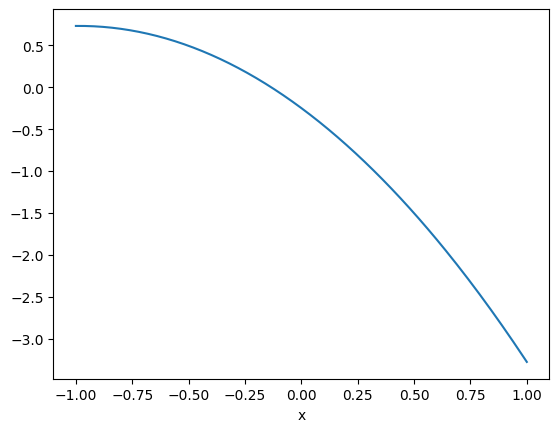

In [6]:
Ax, Ay, As = expansion.get_A(lambdify=True)
#print("Ax:", Ax, "Ay:", Ay, "As:", As)
Ax_ana = Ax(X, Y, S)
Ay_ana = Ay(X, Y, S)
As_ana = As(X, Y, S)

#plot As as a function of x for s=0 and y=0
plt.plot(xa, As_ana[:, 50, 10])
plt.xlabel('x')

(201, 201, 201) (201, 201, 201)
Max difference in Bx: 0.010903331666712424
Max relative difference in By: 0.002137840196075031
Max difference in Bs: 0.0


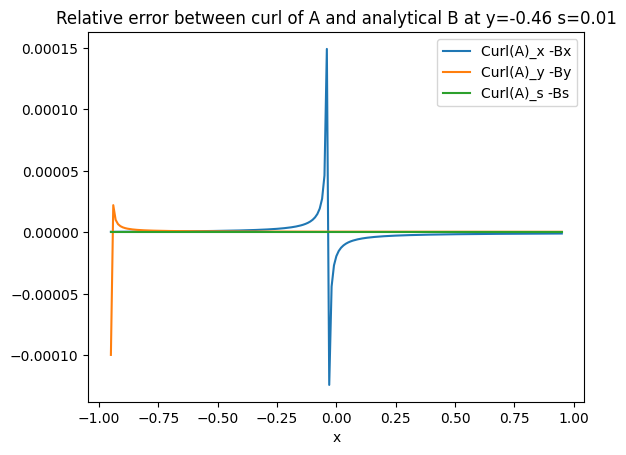

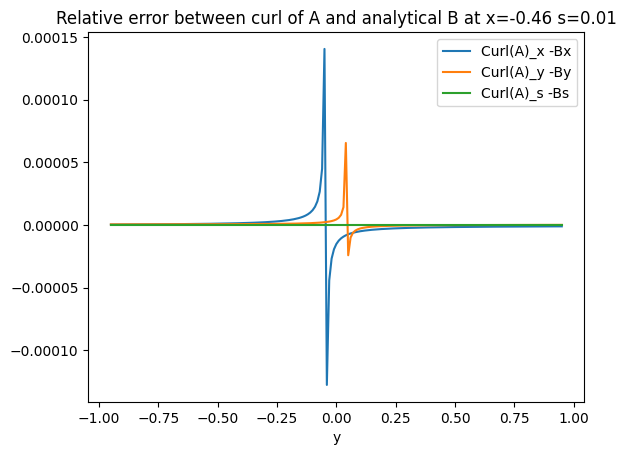

In [7]:
#then take the curl of A from finite differences and compare with the original B field
def curl_3d(Ax, Ay, Az, dx, dy, dz):
  
    # Compute partial derivatives
    dAx_dy = np.gradient(Ax, dy, axis=1)
    dAx_dz = np.gradient(Ax, dz, axis=2)
    dAy_dx = np.gradient(Ay, dx, axis=0)
    dAy_dz = np.gradient(Ay, dz, axis=2)
    dAz_dx = np.gradient(Az, dx, axis=0)
    dAz_dy = np.gradient(Az, dy, axis=1)
    
    # Curl components
    curl_x = dAz_dy - dAy_dz
    curl_y = dAx_dz - dAz_dx
    curl_z = dAy_dx - dAx_dy
    
    return curl_x, curl_y, curl_z

# Compute spacings
dx = xa[1] - xa[0]
dy = ya[1] - ya[0]
ds = sa[1] - sa[0]
# Compute curl
curl_Ax, curl_Ay, curl_As = curl_3d(Ax_ana, Ay_ana, As_ana, dx, dy, ds)
print(curl_Ax.shape, Bx_ana.shape)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_Ax - Bx_ana)))
print("Max relative difference in By:", np.max(np.abs(curl_Ay - By_ana))/np.max(np.abs(By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_As - Bs_ana)))

truncatedx=xa[5:npoints-5]#to avoid boundary effects from finite differences
#truncateds=sa[5:npoints-5]#to avoid boundary effects from finite differences
#position=(45, 54,slice(5,npoints-5))#x=0, y=0, all s
position=( slice(5,npoints-5),54, 101)#all x, y=0, s=0.5

plt.plot(truncatedx, (curl_Ax[position]-Bx_ana[position])/Bx_ana[position], label='Curl(A)_x -Bx')
plt.xlabel('x')
plt.title('Relative error between curl of A and analytical B at y='+str(round(sa[position[1]],2)) +" s="+str(round(sa[position[2]],2)))

plt.plot(truncatedx, (curl_Ay[position]-By_ana[position])/By_ana[position], label='Curl(A)_y -By')
plt.plot(truncatedx, (curl_As[position]-Bs_ana[position])/(Bs_ana[position]+1e-9), label='Curl(A)_s -Bs')

#plt.ylim((np.min((curl_Ay[position]-By_ana[position])/By_ana[position]), np.max((curl_Ay[position]-By_ana[position])/By_ana[position])))
plt.legend()

plt.show()

truncatedy=xa[5:npoints-5]#to avoid boundary effects from finite differences
positiony=( 54,slice(5,npoints-5), 101)#all x, y=0, s=0.5

plt.plot(truncatedy, (curl_Ax[positiony]-Bx_ana[positiony])/Bx_ana[positiony], label='Curl(A)_x -Bx')
plt.xlabel('y')
plt.title('Relative error between curl of A and analytical B at x='+str(round(sa[positiony[0]],2)) +" s="+str(round(sa[positiony[2]],2)))

plt.plot(truncatedy, (curl_Ay[positiony]-By_ana[positiony])/By_ana[positiony], label='Curl(A)_y -By')
plt.plot(truncatedy, (curl_As[positiony]-Bs_ana[positiony])/(Bs_ana[positiony]+1e-9), label='Curl(A)_s -Bs')
#plt.ylim((np.min((curl_Ay[positiony]-By_ana[positiony])/By_ana[positiony]), np.max((curl_Ay[positiony]-By_ana[positiony])/By_ana[positiony])))
plt.legend()

plt.show()


Local Harmonic analysis

In [8]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.0
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    curl_Ax.ravel(),
    curl_Ay.ravel(),
    curl_As.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)
bnianfromcurl=curlfieldmap.harmonic_analysis_at_s(spos=s_fixed,rmin=0.22,rmax=0.7,nr=48, radius=0.04 )
bn=bnianfromcurl.real[:len(b_coeffs)]
an=bnianfromcurl.imag[:len(a_coeffs)]

print("recovered bn(0): ",bn )
print("Original bn(0): ", b_coeffs)
print("recovered an(0): ",an )
print("Original an(0): ", a_coeffs)

recovered bn(0):  [ 1.00000068  1.99822361  0.04093687 -0.37356898]
Original bn(0):  [1, 2, 0.041, 0.04]
recovered an(0):  [ 0.99999833  1.99822228  0.09984601 -0.37356871]
Original an(0):  [1, 2, 0.1, 0.04]


Fourier Transform for the s-independent case

In [9]:
#Since there is no s dependence in the original coefficients i can use fft
bnianfft=curlfieldmap.fft_at_s(spos=s_fixed, r=0.4, radius=0.04)
bnfft=bnianfft.real[:len(b_coeffs)]
print("bn recovered by Fourier transform: ",bnfft )
print("Original bn: ", b_coeffs)

bn recovered by Fourier transform:  [1.00000068 2.00005594 0.04100234 0.04000349]
Original bn:  [1, 2, 0.041, 0.04]


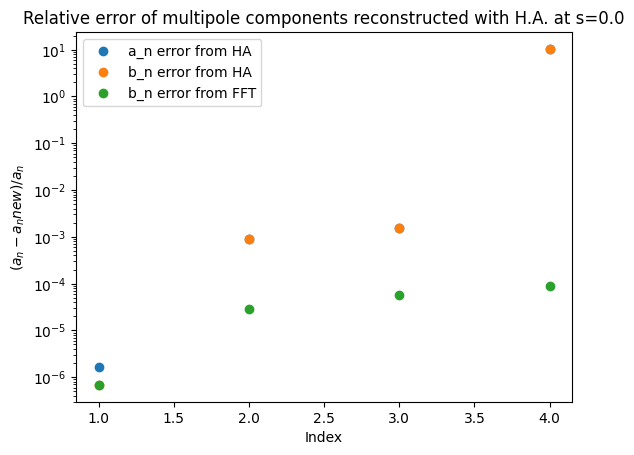

In [ ]:
p=4#how many values to plot

plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bn[:p])/b_coeffs[:p], 'o', label='b_n error from HA')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bnfft[:p])/b_coeffs[:p], 'o', label='b_n error from FFT')
plt.yscale('log')
plt.xlabel('Index')
plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(s_fixed))
plt.legend()
plt.show()

HA along s

In [11]:
svals, bnHA, errorbnHA = curlfieldmap.s_harmonics(order=len(b_coeffs), rmin=0.01, rmax=0.30,nr=30, radius=0.025)

KeyboardInterrupt: 

In [ ]:
import sympy
#evaluate the original coefficients at s=s_fixed
a_coeffs_eval = [sympy.sympify(coeff).subs(s, svals) for (coeff, svals) in zip(a_coeffs, svals)]
b_coeffs_eval = [sympy.sympify(coeff).subs(s, svals) for (coeff, svals) in zip(b_coeffs, svals)]
print("Original a_n(s): ", a_coeffs_eval)

(200, 4)


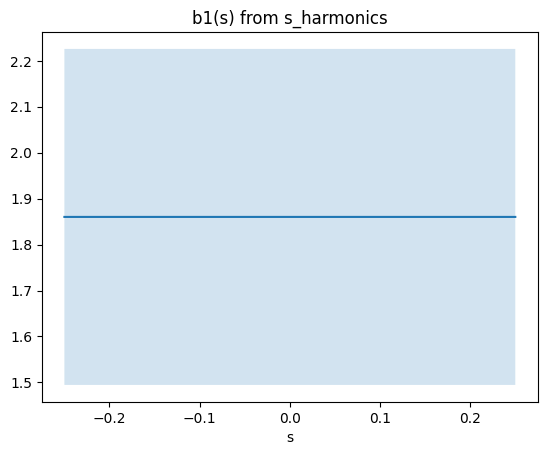

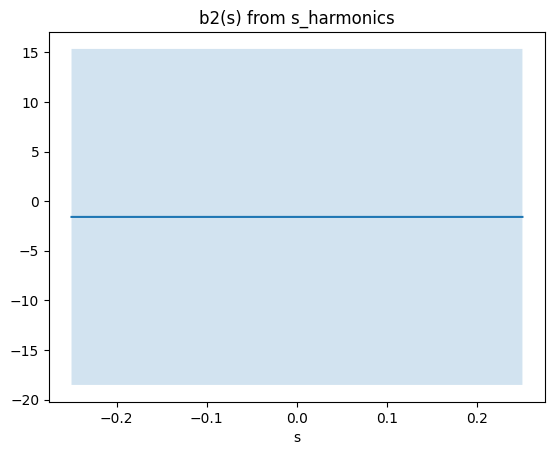

In [ ]:
print(bnHA.shape)
plt.plot(svals, bnHA[:,0], label='recovered b1(s)')
plt.fill_between(svals, bnHA[:,0]-errorbnHA[:,0], bnHA[:,0]+errorbnHA[:,0], alpha=0.2)
plt.xlabel('s')
plt.title('b1(s) from s_harmonics')
plt.legend()
plt.plot(svals, b_coeffs_eval[0], label='original b1(s) in straight coordinates')
plt.show()

plt.plot(svals, bnHA[:,1], label='recovered b2(s)')
plt.fill_between(svals, bnHA[:,1]-errorbnHA[:,1], bnHA[:,1]+errorbnHA[:,1], alpha=0.2)
plt.xlabel('s')
plt.title('b2(s) from s_harmonics')
plt.legend()
plt.show()